In [1]:
# --- Célula 1: Mudar Diretório ---


# Agora o diretório de trabalho é a pasta raiz. A importação absoluta funciona diretamente.
from processamento import PassandoDados

print("Importação bem-sucedida!")

Importação bem-sucedida!


In [2]:
tensores = PassandoDados()
tensores.limite_features = 24000
tensores.limite_labels = 200
tensores.metodo = 'neurokit'

In [3]:
print(tensores.__doc__)

_summary_

        Args:
            limite_features (int, optional): _description_. Defaults to 12000.
            limite_labels (int, optional): _description_. Defaults to None.
            metodo (str, optional): _description_. Defaults to 'neurokit'.
        


In [3]:
# pegando dados processados tensor
sinais, tempos, eventos = tensores.convert_to_tensors()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Processando pacientes: 100%|██████████| 163/163 [00:09<00:00, 17.45paciente/s]


Limite de features: 24000, Limite de labels: 200, Método: neurokit


In [4]:
!python -c "import torch, torchvision; print(torch.__version__, torchvision.__version__)"


2.5.1 0.20.1


In [5]:
eventos.dtype

torch.int64

In [4]:
X = sinais           # [n_amostras, 3, T]
y = eventos          # [n_amostras]

print(X.shape, y.shape)

torch.Size([163, 3, 24000]) torch.Size([163])


Criando DataLoaders

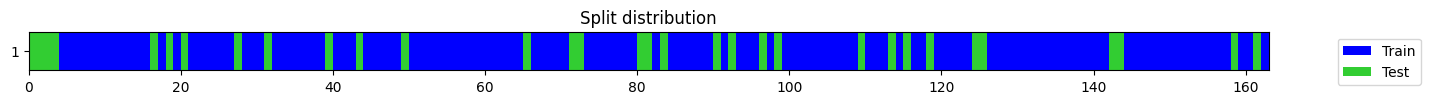

Número de classes no DataLoader: 2


In [6]:
from tsai.all import *

# Criar splits (treino/validação)
splits = get_splits(y, valid_size=0.2, stratify=True)  # 80% treino / 20% validação

# Criar DataLoaders
dls = get_ts_dls(X, y, splits=splits)

dls.c = 2  # Forçar número de classes

print("Número de classes no DataLoader:", dls.c)


In [8]:
# Inspecionar os rótulos no DataLoader
for batch in dls.train:
    inputs, targets = batch
    print("Rótulos únicos:", targets.unique())
    break  # Verifica apenas o primeiro batch

Rótulos únicos: tensor([0, 1])


1. InceptionTime

In [9]:
from torchinfo import summary


n_channels=3
n_classes=2

# Cria modelo InceptionTime
model = InceptionTime(c_in = n_channels, c_out = n_classes) 
# Faz summary
summary(model, input_size=(756, 3, 1200))

Layer (type:depth-idx)                        Output Shape              Param #
InceptionTime                                 [756, 2]                  --
├─InceptionBlock: 1-1                         [756, 128, 1200]          --
│    └─ModuleList: 2-5                        --                        (recursive)
│    │    └─InceptionModule: 3-1              [756, 128, 1200]          69,056
│    │    └─InceptionModule: 3-2              [756, 128, 1200]          77,056
│    │    └─InceptionModule: 3-3              [756, 128, 1200]          77,056
│    └─ModuleList: 2-6                        --                        (recursive)
│    │    └─ConvBlock: 3-4                    [756, 128, 1200]          640
│    └─Add: 2-3                               [756, 128, 1200]          --
│    └─ReLU: 2-4                              [756, 128, 1200]          --
│    └─ModuleList: 2-5                        --                        (recursive)
│    │    └─InceptionModule: 3-5              [756, 128

Através da função ```net.children()``` conseguimos acessar individualmente os módulos implementados na rede. 

https://pytorch.org/docs/stable/nn.html#torch.nn.Module.children

In [ ]:
# list(model.named_children())
list(model.children())

[InceptionBlock(
   (inception): ModuleList(
     (0): InceptionModule(
       (bottleneck): Conv1d(3, 32, kernel_size=(1,), stride=(1,), bias=False)
       (convs): ModuleList(
         (0): Conv1d(32, 32, kernel_size=(39,), stride=(1,), padding=(19,), bias=False)
         (1): Conv1d(32, 32, kernel_size=(19,), stride=(1,), padding=(9,), bias=False)
         (2): Conv1d(32, 32, kernel_size=(9,), stride=(1,), padding=(4,), bias=False)
       )
       (maxconvpool): Sequential(
         (0): MaxPool1d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
         (1): Conv1d(3, 32, kernel_size=(1,), stride=(1,), bias=False)
       )
       (concat): Concat(dim=1)
       (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (act): ReLU()
     )
     (1-5): 5 x InceptionModule(
       (bottleneck): Conv1d(128, 32, kernel_size=(1,), stride=(1,), bias=False)
       (convs): ModuleList(
         (0): Conv1d(32, 32, kernel_size=(39,), stride=

In [ ]:
list(model.children())[-1]

In [ ]:
for batch in dls.train:
    inputs, targets = batch
    print("Formato da entrada:", inputs.shape)  # Deve ser [756, 3, 1200]
    print("Formato do target:", targets.shape)  # Deve ser [756]
    print("Tipo do target:", targets.dtype)    # Deve ser torch.int64
    print("Rótulos únicos:", targets.unique()) # Deve ser tensor([0, 1])
    break

Formato da entrada: torch.Size([64, 3, 1200])
Formato do target: torch.Size([64])
Tipo do target: torch.int64
Rótulos únicos: tensor([0, 1])


In [ ]:
print("Número de classes no DataLoader:", dls.c)

Número de classes no DataLoader: 2


In [ ]:
from torch.nn import CrossEntropyLoss


# Modelo pré-treinado InceptionTime
model = InceptionTime(dls.vars, dls.c)

learn = Learner(dls, model, loss_func=CrossEntropyLoss(), metrics=accuracy)

learn.fit_one_cycle(10, 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.556001,0.660792,0.860927,01:01
1,0.487338,0.501471,0.860927,01:02
2,0.456320,0.412392,0.860927,01:02
3,0.433452,0.402902,0.860927,01:07
4,0.415513,0.405287,0.860927,01:16
5,0.404232,0.394282,0.867550,01:04
6,0.389950,0.402411,0.860927,01:00
7,0.378864,0.421424,0.860927,01:00
8,0.365313,0.415183,0.860927,00:59
9,0.351886,0.414503,0.854305,01:11


2. ResNet1d

In [ ]:

# Cria modelo ResNet1d
model = ResNet(dls.vars, dls.c)
# Faz summary
summary(model, input_size=(756, 3, 1200))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [756, 2]                  --
├─ResBlock: 1-1                          [756, 64, 1200]           --
│    └─ConvBlock: 2-1                    [756, 64, 1200]           --
│    │    └─Conv1d: 3-1                  [756, 64, 1200]           1,344
│    │    └─BatchNorm1d: 3-2             [756, 64, 1200]           128
│    │    └─ReLU: 3-3                    [756, 64, 1200]           --
│    └─ConvBlock: 2-2                    [756, 64, 1200]           --
│    │    └─Conv1d: 3-4                  [756, 64, 1200]           20,480
│    │    └─BatchNorm1d: 3-5             [756, 64, 1200]           128
│    │    └─ReLU: 3-6                    [756, 64, 1200]           --
│    └─ConvBlock: 2-3                    [756, 64, 1200]           --
│    │    └─Conv1d: 3-7                  [756, 64, 1200]           12,288
│    │    └─BatchNorm1d: 3-8             [756, 64, 1200]           128
│

In [ ]:
model = ResNet(dls.vars, dls.c)
learn = Learner(dls, model, loss_func=CrossEntropyLoss(), metrics=accuracy)
learn.fit_one_cycle(10, 1e-3)


epoch,train_loss,valid_loss,accuracy,time
0,0.533442,0.673547,0.860927,00:27
1,0.472505,0.511051,0.860927,00:25
2,0.433443,0.421623,0.860927,00:27
3,0.415556,0.402480,0.860927,00:32
4,0.398447,0.420913,0.860927,00:30
5,0.384926,0.435608,0.860927,00:31
6,0.369509,0.436684,0.860927,00:31
7,0.353718,0.463853,0.860927,00:31
8,0.337582,0.445638,0.854305,00:31
9,0.322396,0.446278,0.854305,00:32


3. XResNet1d

In [ ]:
from tsai.models.XResNet1d import xresnet1d18

# artigo que utilizou o modelo 
# https://ieeexplore.ieee.org/document/11012832 
model = xresnet1d18(c_in=dls.vars, c_out=dls.c)

summary(model, input_size=(756, 3, 1200))

Layer (type:depth-idx)                        Output Shape              Param #
XResNet                                       [756, 2]                  --
├─ConvLayer: 1-1                              [756, 32, 600]            --
│    └─Conv1d: 2-1                            [756, 32, 600]            288
│    └─BatchNorm1d: 2-2                       [756, 32, 600]            64
│    └─ReLU: 2-3                              [756, 32, 600]            --
├─ConvLayer: 1-2                              [756, 32, 600]            --
│    └─Conv1d: 2-4                            [756, 32, 600]            3,072
│    └─BatchNorm1d: 2-5                       [756, 32, 600]            64
│    └─ReLU: 2-6                              [756, 32, 600]            --
├─ConvLayer: 1-3                              [756, 64, 600]            --
│    └─Conv1d: 2-7                            [756, 64, 600]            6,144
│    └─BatchNorm1d: 2-8                       [756, 64, 600]            128
│    └─ReLU:

In [ ]:
learn = Learner(dls, model, loss_func=CrossEntropyLoss(), metrics=accuracy)
learn.fit_one_cycle(10, 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.750135,0.620855,0.860927,00:14
1,0.588789,0.400509,0.860927,00:11
2,0.516537,0.423096,0.860927,00:15
3,0.466214,0.429493,0.854305,00:15
4,0.430499,0.398734,0.867550,00:18
5,0.403705,0.437622,0.854305,00:17
6,0.380963,0.427949,0.854305,00:16
7,0.362955,0.427343,0.854305,00:15
8,0.345079,0.426512,0.860927,00:14
9,0.331184,0.428255,0.860927,00:14


4. TSMixer

In [ ]:
# #from tsai.models import TSMixer
# from tsai.models.TSMixer import TSMixer


# model = TSMixer(dls.vars, dls.c)

# summary(model, input_size=(756, 3, 1200))

In [ ]:
# learn = Learner(dls, model, loss_func=CrossEntropyLoss(), metrics=accuracy)
# learn.fit_one_cycle(10, 1e-3)

5. Transformer

In [ ]:
from tsai.models.TransformerModel import TransformerModel

model = TransformerModel(dls.vars, dls.c)

summary(model, input_size=(756, 3, 1200))

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [756, 2]                  --
├─Permute: 1-1                                [1200, 756, 3]            --
├─Linear: 1-2                                 [1200, 756, 64]           256
├─ReLU: 1-3                                   [1200, 756, 64]           --
├─TransformerEncoder: 1-4                     [1200, 756, 64]           --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1200, 756, 64]           33,472
│    └─LayerNorm: 2-2                         [1200, 756, 64]           128
├─Transpose: 1-5                              [756, 1200, 64]           --
├─Max: 1-6                                    [756, 64]                 --
├─ReLU: 1-7                                   [756, 64]                 --
├─Linear: 1-8                                 [756, 2]                  130
Total params:

In [ ]:
learn = Learner(dls, model, loss_func=CrossEntropyLoss(), metrics=accuracy)
learn.fit_one_cycle(10, 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,1.023672,0.840299,0.152318,00:24
1,0.761237,0.404393,0.860927,00:24
2,0.619397,0.417115,0.860927,00:27
3,0.549011,0.403411,0.860927,00:24
4,0.506087,0.404115,0.860927,00:22
5,0.479836,0.403354,0.860927,00:24
6,0.463946,0.403255,0.860927,00:24
7,0.448708,0.403315,0.860927,00:22
8,0.438223,0.403309,0.860927,00:22
9,0.430825,0.403309,0.860927,00:21


ECG_CRNN

Com o TorchECG, você tem acesso a modelos específicos para sinais ECG, incluindo 
- CRNNs, 
- TResNet, 
- U-Net 
- variantes de ResNet, 
todos adaptados para dados contínuos de ECG, que é exatamente o 
seu caso (sinais contínuos de 3 derivações).


Estrutura dos modelos

O ECG_CRNN é o principal modelo para classificação e segmentação de sinais ECG.\
Você pode escolher diferentes backbones de CNN, incluindo ResNet, TResNet, Xception, etc.\
Ele aceita classes (número de classes) e n_leads (quantas derivações você tem, no seu caso 3).



O torch_ecg não é um único modelo pré-treinado “genérico”. Ele é uma biblioteca com vários tipos de modelos voltados para ECG:

- ECG_CRNN → Convolução + RNN, bom para classificação de sinais contínuos.
- TResNet → Variantes de ResNet otimizadas para ECG.
- U-Net / U-Net++ / U-Squared → Para segmentação de batimentos ou ondas no ECG.
- RR-LSTM → Focado em sequências de intervalos R-R.

💡 Então, você precisa escolher qual modelo usar, dependendo da tarefa:

Tarefa	Modelo recomendado\
Classificação de sinais (ex: normal / arritmia)	ECG_CRNN, TResNet\
Segmentação (detectar ondas específicas)	U-Net, U-Net++\
Série temporal baseada em intervalos R-R	RR-LSTM

In [ ]:
len(torch.unique(y))

2

In [ ]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from torch_ecg.models.ecg_crnn import ECG_CRNN
from sklearn.model_selection import train_test_split

# ======================
# 1️⃣ Split treino / validação
# ======================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val, y_val)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=32, shuffle=False)

# ======================
# 2️⃣ Criar Modelo
# ======================
classes = ["0", "1"]  # ou simplesmente 2

n_leads = X.size()[1]  # 3 derivações
model = ECG_CRNN(classes, n_leads)

# ======================
# 3️⃣ Definir Loss e Otimizador
# ======================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ======================
# 4️⃣ Treinamento Simples
# ======================
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    
    for batch_X, batch_y in train_dl:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_X.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == batch_y).sum().item()
        total += batch_X.size(0)
    
    train_loss /= total
    train_acc = correct / total
    
    # Validação
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_X, batch_y in val_dl:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_X.size(0)
    val_loss /= total
    val_acc = correct / total
    
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


c:\Users\danie\anaconda3\envs\regressao_cox\Lib\site-packages\torch_ecg\models\ecg_crnn.py:79: RuntimeWarning: No config is provided, using default config.
  warnings.warn("No config is provided, using default config.", RuntimeWarning)


Epoch 1/10 | Train Loss: 0.6429, Train Acc: 0.8593 | Val Loss: 0.4214, Val Acc: 0.8618
Epoch 2/10 | Train Loss: 0.4102, Train Acc: 0.8626 | Val Loss: 0.4229, Val Acc: 0.8618
Epoch 3/10 | Train Loss: 0.3993, Train Acc: 0.8626 | Val Loss: 0.4252, Val Acc: 0.8618
Epoch 4/10 | Train Loss: 0.3948, Train Acc: 0.8626 | Val Loss: 0.4340, Val Acc: 0.8618
Epoch 5/10 | Train Loss: 0.3893, Train Acc: 0.8626 | Val Loss: 0.4706, Val Acc: 0.8618
Epoch 6/10 | Train Loss: 0.3557, Train Acc: 0.8659 | Val Loss: 0.5097, Val Acc: 0.8487
Epoch 7/10 | Train Loss: 0.3350, Train Acc: 0.8675 | Val Loss: 0.5985, Val Acc: 0.8618
Epoch 8/10 | Train Loss: 0.3195, Train Acc: 0.8626 | Val Loss: 0.5137, Val Acc: 0.8487
Epoch 9/10 | Train Loss: 0.3118, Train Acc: 0.8675 | Val Loss: 0.7171, Val Acc: 0.8553
Epoch 10/10 | Train Loss: 0.2813, Train Acc: 0.8758 | Val Loss: 0.6525, Val Acc: 0.8289
